<a href="https://colab.research.google.com/github/SotaYoshida/Lecture_DataScience/blob/master/Kadai_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 課題X

提出方法はJupyterNotebookに課題に相当する部分を付け足して提出しても良いし、
保存した図をワードか何かに貼り付けて整形しても良い.

授業では扱わなかった条件分岐(if文)を使うので注意。


なお、講義でも注意したように、株価や仮想通貨の取引は、
以下のようなチンケなルールでは間違いなく「勝てない」ので、
実際の運用はしないこと。

---

https://drive.google.com/file/d/11lLR1lNcIWamQmNH9KOB4ikcBTD9XSlX/view?usp=sharing

に収録されているのは、仮想通貨BitCoin(BTC)および、アルトコイン(ETH,XEM)の五分足の終値のデータで、2017年9月から12月に渡るデータである。


一方で、
https://drive.google.com/file/d/1kcTQUq4lzAD_1d6y1M_24fSgvtrwKYdk/view?usp=sharing
に収録されているのは、同様のデータで、より長期間に渡るものである。


これらをマイドライブ以下のColab_csvとでも名付けたディレクトリに入れたと仮定して、以下では作業を行う。





---

取得したデータを、GoogleColab上の適当な名前のフォルダに入れる。

まずGoogleドライブをマウントして

In [1]:
from google.colab import drive
drive.mount('./gdrive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at ./gdrive


(作成していない場合)マイドライブのすぐ下に、Colab_csvという名前のフォルダを作ります

In [2]:
!mkdir  'gdrive/My Drive/Colab_csv' #一度実行すればOK  

mkdir: cannot create directory ‘gdrive/My Drive/Colab_csv’: File exists


**このフォルダの中に、ダウンロードしたファイルをおいておきましょう。**

マウントが成功した場合、以下のコードでフォルダの中にあるファイルのリストを表示できます。

In [3]:
!ls  './gdrive/My Drive/Colab_csv/' 

201709-12.csv
all.csv
co2_emissions_tonnes_per_person.xlsx
energy_production_total.xlsx
flu.csv
income_per_person_gdppercapita_ppp_inflation_adjusted.csv
mean_years_in_school_women_percent_men_25_to_34_years.csv
population_total.csv


以下では```201709-12.csv```のみを用います。

まずはファイルを読み込んでデータフレームに格納します

In [30]:
import pandas as pd
df = pd.read_csv('./gdrive/My Drive/Colab_csv/201709-12.csv')
print(df)

       Unnamed: 0        date   time        BTC      ETH       XEM
0               0  2017/09/01  00:00   519395.0      NaN   37.2000
1               1  2017/09/01  00:05   519295.0      NaN   37.2100
2               2  2017/09/01  00:10   520775.0      NaN   37.3099
3               3  2017/09/01  00:15   521235.0      NaN   37.5001
4               4  2017/09/01  00:20   521005.0      NaN   37.7001
...           ...         ...    ...        ...      ...       ...
35131       35131  2017/12/31  23:35  1574085.0  85000.0  107.4997
35132       35132  2017/12/31  23:40  1583000.0  84995.0  107.7996
35133       35133  2017/12/31  23:45  1577100.0  84995.0  107.5000
35134       35134  2017/12/31  23:50  1573495.0  84900.0  106.6000
35135       35135  2017/12/31  23:55  1575705.0  85005.0  106.9693

[35136 rows x 6 columns]


とりあえずBitcoin(BTC)の値だけ使うことにしてリストにいれてしまいましょう  
天下り的な説明ですが、以下のように行います。

特定の列の値のみを取得するときには、["key"]で指定します。

In [5]:
print( df["BTC"])

0         519395.0
1         519295.0
2         520775.0
3         521235.0
4         521005.0
           ...    
35131    1574085.0
35132    1583000.0
35133    1577100.0
35134    1573495.0
35135    1575705.0
Name: BTC, Length: 35136, dtype: float64


特定の行の値を取得するときは、loc["key"]もしくはloc[インデックス]で、

In [6]:
print(df.loc[35135])

Unnamed: 0          35135
date           2017/12/31
time                23:55
BTC           1.57570e+06
ETH                 85005
XEM               106.969
Name: 35135, dtype: object


といった具合です。

当面、BTCの値と、日付、時刻のみを使うことにしましょう。

In [7]:
BTC =  list(df["BTC"]) ## "BTC"列の値を取得してリストに格納
dates = list(df["date"])
times = list(df["time"]) #time

print(BTC)
print(dates)
print(times)

[519395.0, 519295.0, 520775.0, 521235.0, 521005.0, 520940.0, 520710.0, 519205.0, 519425.0, 518965.0, 520065.0, 521150.0, 521770.0, 521995.0, 522045.0, 522245.0, 522000.0, 521525.0, 521415.0, 521375.0, 521395.0, 520905.0, 521060.0, 520225.0, 519680.0, 520320.0, 519565.0, 519100.0, 520205.0, 521210.0, 521590.0, 521220.0, 520720.0, 520575.0, 520950.0, 521920.0, 521820.0, 522285.0, 521285.0, 521330.0, 521205.0, 521405.0, 521540.0, 521700.0, 521945.0, 523810.0, 523480.0, 522945.0, 523930.0, 523810.0, 522200.0, 520770.0, 521865.0, 522300.0, 520885.0, 521460.0, 520880.0, 521205.0, 521035.0, 520535.0, 520045.0, 520265.0, 520240.0, 519570.0, 520445.0, 520645.0, 521080.0, 521615.0, 521900.0, 521735.0, 521910.0, 521625.0, 522055.0, 522000.0, 521865.0, 521650.0, 521535.0, 521565.0, 521535.0, 521675.0, 521795.0, 521200.0, 521270.0, 521070.0, 521305.0, 521940.0, 521880.0, 522495.0, 522465.0, 522315.0, 522895.0, 522995.0, 522735.0, 522995.0, 523690.0, 523935.0, 523755.0, 522765.0, 522840.0, 522880.0,

(追記) 全期間のデータから2017年のみを抽出する場合は

In [43]:
print(df.query('date.str.contains("2017/")', engine='python')) ## date列の中から　引用符内の条件を持つものだけを抽出
### あるいは
subdf  = df.query('date.str.contains("2017/")', engine='python')
###　として名前を付け替えても良い (全期間データでない)

       Unnamed: 0        date   time        BTC      ETH       XEM
0               0  2017/09/01  00:00   519395.0      NaN   37.2000
1               1  2017/09/01  00:05   519295.0      NaN   37.2100
2               2  2017/09/01  00:10   520775.0      NaN   37.3099
3               3  2017/09/01  00:15   521235.0      NaN   37.5001
4               4  2017/09/01  00:20   521005.0      NaN   37.7001
...           ...         ...    ...        ...      ...       ...
35131       35131  2017/12/31  23:35  1574085.0  85000.0  107.4997
35132       35132  2017/12/31  23:40  1583000.0  84995.0  107.7996
35133       35133  2017/12/31  23:45  1577100.0  84995.0  107.5000
35134       35134  2017/12/31  23:50  1573495.0  84900.0  106.6000
35135       35135  2017/12/31  23:55  1575705.0  85005.0  106.9693

[35136 rows x 6 columns]


これを応用すれば、特定の

*x軸の設定が面倒なのですが、とりあえずBitcoinの値だけでもプロットしてみましょう。*

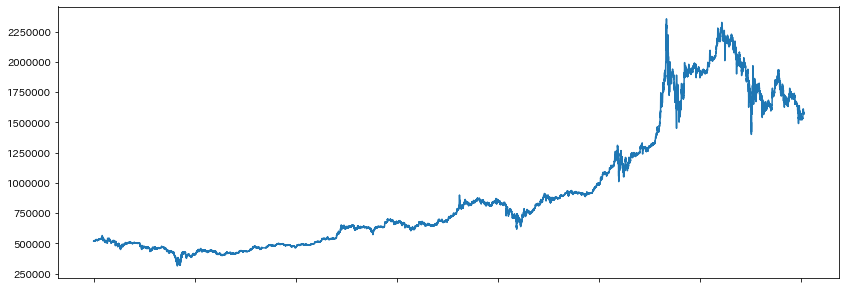

In [23]:
from matplotlib import pyplot as plt 
!pip install japanize-matplotlib 
import japanize_matplotlib 

fig = plt.figure(figsize=(14,5))
ax = fig.add_subplot(1,1,1)
ax.plot(BTC)
ticks = []
for i,tmp in enumerate(dates):
    if i % 5000 == 0 :
        ticks += [tmp] #+ "/"+times[i]
ax.set_xticks(range(0,len(dates),5000))
ax.set_xticklabels(ticks)
plt.show()

まず、10000円を元手に2017/09/01から1日置きに毎日正午に買い・売りを繰り返してみましょう。

今の場合、datesとtimesは長さが同じリストですので、timesでループを回せば良さそうです。


In [9]:
orgJPY=10000
tJPY= orgJPY
for i, tmp in enumerate(times):
  if tmp != "12:00": #tmpが"12:00"と等しくない(!=)とき、という意味
      continue #正午以外はなんの作業もしない
  if tJPY > 0.0 : ## 所持JPYが有限→買う
    tBTC = tJPY/BTC[i]
    tJPY = 0.
  else:
    tJPY = BTC[i] * tBTC
    tBTC = 0.
#  print(dates[i], "総資産", str("%12.1f" % (tJPY + tBTC*BTC[i])), "円")
print("最終日: 日本円", tJPY, " BTC:", tBTC)
print("総資産", str("%12.1f" % (tJPY + tBTC*BTC[i])), "円")

最終日: 日本円 29974.010076325827  BTC: 0.0
総資産      29974.0 円


注)  実際の取引では、購入の最小単位が存在すること、買い板・売り板が順次処理されていくことや、相場の加熱時のアクセスのしにくさなども考慮しなければならないが、「注文は即座に反映され、売買が必ず瞬間的に成立する」という、非現実的な仮定を置く.


#### if文などを駆使して、より条件を複雑化させてみましょう。

たとえば、一度に全部売り買いするのではなく、少口で買い売りを繰り返すのもよいでしょう。
(実際に、仮想通貨などの売買板を眺めていると、プログラムを組んで自動化していると思しき大量の少口の売買が並んでいるのが見えたりします。)

3-5程度違う売買ルールを作って、最終的な金額を計算してください。


また、それらのルールを、


1.   2017年9月-12月だけでなく別期間に適用
(注意:全期間使うとGoogle Colab.Google Colab.では扱えませんので、適当に期間を区切って使ってください))
2.   他の通貨(ETH,XEM)に適用
3.   全く別期間の株価に適用

するなどして、売買ルールの性能(ある種の汎化性能)を評価してみましょう。



### (2月15日追記)

If文を授業中に使ってなかったので、もう少し例を出しながら補足します。


ルール2:

In [21]:
def rule1(tJPY,tBTC,BTCvalue): ## 小出しに買う戦法
    if tJPY > 0.0 :
        tBTC = (0.5 * tJPY) / BTCvalue 
        tJPY  = tJPY - 0.5 * tJPY
    return tJPY, tBTC          
def rule2(tJPY,tBTC,BTCvalue): ## 全部買う　全部売る
    if tJPY > 0.0:
        tBTC = tJPY/BTCvalue        
        tJPY =0.0
    else: 
        tJPY = BTCvalue * tBTC 
        tBTC = 0.0
    return tJPY, tBTC

orgJPY=1000000
tJPY= orgJPY
tBTC= 0.0
for i, tmp in enumerate(times):  
    if i == 1000:
        break   
    if tmp == "8:00" or  tmp == "20:00":  
      tJPY,tBTC = rule1(tJPY,tBTC, BTC[i]) 
    elif tmp == "15:00":
      tJPY,tBTC = rule2(tJPY,tBTC, BTC[i])
    else:
        continue 
    print( tJPY, tBTC, BTC[i])
        
print("最終日: 日本円", tJPY, " BTC:", tBTC)
print("総資産", str("%12.1f" % (tJPY + tBTC*BTC[i])), "円")

0.0 1.9136009185284408 522575.0
0.0 1.9136009185284408 528060.0
1017088.4562024589 0.0 531505.0
508544.22810122947 0.9625776820670044 528315.0
0.0 0.9395302352800877 541275.0
0.0 0.9395302352800877 523375.0
最終日: 日本円 0.0  BTC: 0.9395302352800877
総資産     485953.2 円


売買ルールは別でクラスや関数に(作業をパッケージ化)するのが良いです。